In [1]:
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.0 MB/s eta 0:00:00


In [2]:
import os
import glob
import random
import shutil

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q "/content/drive/MyDrive/yolo_bbox.zip" -d "/content/"

In [5]:
# ====== 1. 원본 폴더 설정 (압축 푼 위치 기준) ======
ROOT = '/content'

IMAGES_ALL_DIR = os.path.join(ROOT, 'imege')
LABELS_OC_ALL_DIR = os.path.join(ROOT, 'labels_openclose')
LABELS_FE_ALL_DIR = os.path.join(ROOT, 'labels_fullempty')

# ====== 2. 최종 데이터셋 루트 두 개 ======
DATASET_OC_ROOT = '/content/dataset_openclose'
DATASET_FE_ROOT = '/content/dataset_fullempty'

# 공통적으로 쓸 함수 위해 폴더 미리 만들기
def make_dataset_dirs(root):
    images_train = os.path.join(root, 'images', 'train')
    images_val   = os.path.join(root, 'images', 'val')
    labels_train = os.path.join(root, 'labels', 'train')
    labels_val   = os.path.join(root, 'labels', 'val')
    for d in [images_train, images_val, labels_train, labels_val]:
        os.makedirs(d, exist_ok=True)
    return images_train, images_val, labels_train, labels_val

IM_OC_TRAIN, IM_OC_VAL, LB_OC_TRAIN, LB_OC_VAL = make_dataset_dirs(DATASET_OC_ROOT)
IM_FE_TRAIN, IM_FE_VAL, LB_FE_TRAIN, LB_FE_VAL = make_dataset_dirs(DATASET_FE_ROOT)

# ====== 3. 파라미터 ======
IMG_EXTS = [".jpg", ".jpeg", ".png"]
VAL_RATIO = 0.2   # 80% train, 20% val

# ====== 4. 이미지 리스트 수집 ======
def get_all_images(img_dir):
    paths = []
    for ext in IMG_EXTS:
        paths.extend(glob.glob(os.path.join(img_dir, f"*{ext}")))
    return sorted(paths)

all_images = get_all_images(IMAGES_ALL_DIR)
print(f"[INFO] Found {len(all_images)} images in images_all")

# ====== 5. 라벨 존재 여부 체크 (두 라벨 다 있는 것만 사용) ======
valid_bases = []

for img_path in all_images:
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl_oc = os.path.join(LABELS_OC_ALL_DIR, base + ".txt")
    lbl_fe = os.path.join(LABELS_FE_ALL_DIR, base + ".txt")

    if os.path.exists(lbl_oc) and os.path.exists(lbl_fe):
        valid_bases.append(base)
    else:
        print(f"[SKIP] '{base}' -> openclose or fullempty label missing")

print(f"[INFO] Valid samples: {len(valid_bases)}")

# ====== 6. train/val split ======
random.seed(42)
random.shuffle(valid_bases)

n_total = len(valid_bases)
n_val = int(n_total * VAL_RATIO)
val_bases = set(valid_bases[:n_val])
train_bases = set(valid_bases[n_val:])

print(f"[SPLIT] train: {len(train_bases)}, val: {len(val_bases)}")

# ====== 7. 복사 함수 ======
def find_image_path(base):
    for ext in IMG_EXTS:
        cand = os.path.join(IMAGES_ALL_DIR, base + ext)
        if os.path.exists(cand):
            return cand
    return None

def copy_for_both_datasets(base):
    img_src = find_image_path(base)
    if img_src is None:
        print(f"[WARN] Image not found for '{base}', skip.")
        return

    lbl_oc_src = os.path.join(LABELS_OC_ALL_DIR, base + ".txt")
    lbl_fe_src = os.path.join(LABELS_FE_ALL_DIR, base + ".txt")

    # train or val ?
    is_train = base in train_bases

    # ---------- open/close dataset ----------
    if is_train:
        img_dst_oc = os.path.join(IM_OC_TRAIN, os.path.basename(img_src))
        lbl_dst_oc = os.path.join(LB_OC_TRAIN, base + ".txt")
    else:
        img_dst_oc = os.path.join(IM_OC_VAL, os.path.basename(img_src))
        lbl_dst_oc = os.path.join(LB_OC_VAL, base + ".txt")

    shutil.copy2(img_src, img_dst_oc)
    shutil.copy2(lbl_oc_src, lbl_dst_oc)

    # ---------- full/empty dataset ----------
    if is_train:
        img_dst_fe = os.path.join(IM_FE_TRAIN, os.path.basename(img_src))
        lbl_dst_fe = os.path.join(LB_FE_TRAIN, base + ".txt")
    else:
        img_dst_fe = os.path.join(IM_FE_VAL, os.path.basename(img_src))
        lbl_dst_fe = os.path.join(LB_FE_VAL, base + ".txt")

    shutil.copy2(img_src, img_dst_fe)
    shutil.copy2(lbl_fe_src, lbl_dst_fe)

    print(f"[COPY] {base} -> {'train' if is_train else 'val'}")

# ====== 8. 전체 복사 실행 ======
for base in valid_bases:
    copy_for_both_datasets(base)

print("\n[DONE] dataset_openclose & dataset_fullempty ready.")


[INFO] Found 515 images in images_all
[SKIP] 'photo_normal_001' -> openclose or fullempty label missing
[SKIP] 'photo_normal_003' -> openclose or fullempty label missing
[SKIP] 'photo_normal_011' -> openclose or fullempty label missing
[SKIP] 'photo_normal_084' -> openclose or fullempty label missing
[INFO] Valid samples: 511
[SPLIT] train: 409, val: 102
[COPY] photo_normal_252 -> val
[COPY] photo_normal_218 -> val
[COPY] photo_normal_347 -> val
[COPY] photo_normal_132 -> val
[COPY] photo_normal_312 -> val
[COPY] photo_normal_097 -> val
[COPY] photo_normal_469 -> val
[COPY] photo_normal_187 -> val
[COPY] photo_normal_204 -> val
[COPY] photo_normal_243 -> val
[COPY] photo_normal_389 -> val
[COPY] photo_normal_478 -> val
[COPY] photo_normal_098 -> val
[COPY] photo_normal_151 -> val
[COPY] photo_normal_403 -> val
[COPY] photo_normal_035 -> val
[COPY] photo_normal_012 -> val
[COPY] photo_normal_125 -> val
[COPY] photo_normal_407 -> val
[COPY] photo_normal_168 -> val
[COPY] photo_normal_376

In [6]:
oc_yaml = """
path: /content/dataset_openclose

train: images/train
val: images/val

names:
  0: open
  1: close
"""

with open('/content/data_openclose.yaml', 'w') as f:
    f.write(oc_yaml)

print(open('/content/data_openclose.yaml').read())



path: /content/dataset_openclose

train: images/train
val: images/val

names:
  0: open
  1: close



In [7]:
fe_yaml = """
path: /content/dataset_fullempty

train: images/train
val: images/val

names:
  0: empty
  1: full
"""

with open('/content/data_fullempty.yaml', 'w') as f:
    f.write(fe_yaml)

print(open('/content/data_fullempty.yaml').read())



path: /content/dataset_fullempty

train: images/train
val: images/val

names:
  0: empty
  1: full



In [8]:
from ultralytics import YOLO

# 기본 YOLOv8n 백본에서 시작
model_oc = YOLO('yolov8n.pt')

results_oc = model_oc.train(
    data='/content/data_openclose.yaml',
    epochs=100,
    imgsz=640,
    project='runs_openclose',
    name='yolov8n_openclose',
    exist_ok=True,
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_openclose.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=F

In [9]:
model_fe = YOLO('yolov8n.pt')

results_fe = model_fe.train(
    data='/content/data_fullempty.yaml',
    epochs=100,
    imgsz=640,
    project='runs_fullempty',
    name='yolov8n_fullempty',
    exist_ok=True,
)


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fullempty.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_fullempty, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

In [10]:
import os

print("Open/Close best:",
      [p for p in glob.glob('/content/runs_openclose/**/best.pt', recursive=True)])

print("Full/Empty best:",
      [p for p in glob.glob('/content/runs_fullempty/**/best.pt', recursive=True)])


Open/Close best: ['/content/runs_openclose/yolov8n_openclose/weights/best.pt']
Full/Empty best: ['/content/runs_fullempty/yolov8n_fullempty/weights/best.pt']


In [11]:
import shutil

drive_save_dir = '/content/drive/MyDrive/yolo_box_trained'
os.makedirs(drive_save_dir, exist_ok=True)

shutil.copy2('/content/runs_openclose/yolov8n_openclose/weights/best.pt',
             os.path.join(drive_save_dir, 'best_openclose.pt'))

shutil.copy2('/content/runs_fullempty/yolov8n_fullempty/weights/best.pt',
             os.path.join(drive_save_dir, 'best_fullempty.pt'))

print("Saved to:", drive_save_dir)


Saved to: /content/drive/MyDrive/yolo_box_trained


## 평가 및 시각화

In [12]:
OC_WEIGHT = "/content/runs_openclose/yolov8n_openclose/weights/best.pt"
FE_WEIGHT = "/content/runs_fullempty/yolov8n_fullempty/weights/best.pt"

OC_DATA = "/content/data_openclose.yaml"
FE_DATA = "/content/data_fullempty.yaml"

OC_VAL_IMG_DIR = "/content/dataset_openclose/images/val"
FE_VAL_IMG_DIR = "/content/dataset_fullempty/images/val"


In [13]:
from ultralytics import YOLO

# 1) open/close 모델
model_oc = YOLO(OC_WEIGHT)
metrics_oc = model_oc.val(
    data=OC_DATA,
    imgsz=640,
    split="val"   # val 셋 기준 평가
)

print("=== Open/Close 모델 성능 ===")
print(f"mAP50-95: {metrics_oc.box.map:.4f}")
print(f"mAP50   : {metrics_oc.box.map50:.4f}")
print(f"mAP75   : {metrics_oc.box.map75:.4f}")
print("per-class mAP50:", metrics_oc.box.maps)   # [open, close] 순서


# 2) full/empty 모델
model_fe = YOLO(FE_WEIGHT)
metrics_fe = model_fe.val(
    data=FE_DATA,
    imgsz=640,
    split="val"
)

print("\n=== Full/Empty 모델 성능 ===")
print(f"mAP50-95: {metrics_fe.box.map:.4f}")
print(f"mAP50   : {metrics_fe.box.map50:.4f}")
print(f"mAP75   : {metrics_fe.box.map75:.4f}")
print("per-class mAP50:", metrics_fe.box.maps)   # [empty, full] 순서


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3057.2±602.9 MB/s, size: 96.7 KB)
val: Scanning /content/dataset_openclose/labels/val.cache... 102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 102/102 220.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3it/s 3.1s
                   all        102        408      0.999      0.996      0.995      0.813
                  open         48        192      0.997          1      0.995      0.813
                 close         54        216          1      0.992      0.995      0.813
Speed: 4.6ms preprocess, 5.7ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /content/runs/detect/val
=== Open/Close 모델 성능 ===
mAP50-95: 0.8130
mAP50   : 0.9950
mAP75   : 0.9243
per-class mAP50: [  

[Open/Close] val images: 102장
샘플 이미지 (open/close):
   /content/dataset_openclose/images/val/photo_normal_180.jpg
   /content/dataset_openclose/images/val/photo_normal_242.jpg
   /content/dataset_openclose/images/val/photo_normal_478.jpg

0: 384x640 4 opens, 13.9ms
1: 384x640 4 closes, 13.9ms
2: 384x640 4 opens, 13.9ms
Speed: 2.0ms preprocess, 13.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs_vis_oc/openclose_samples

[Open/Close] 탐지 결과 시각화:


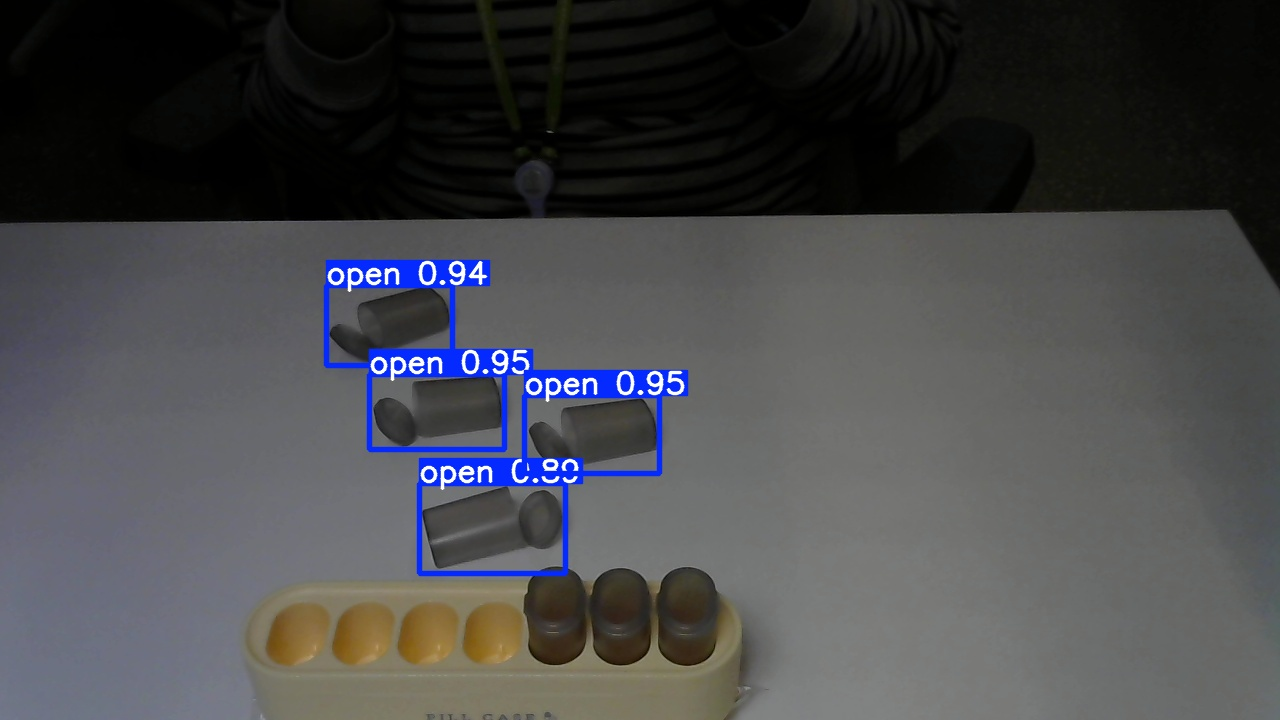

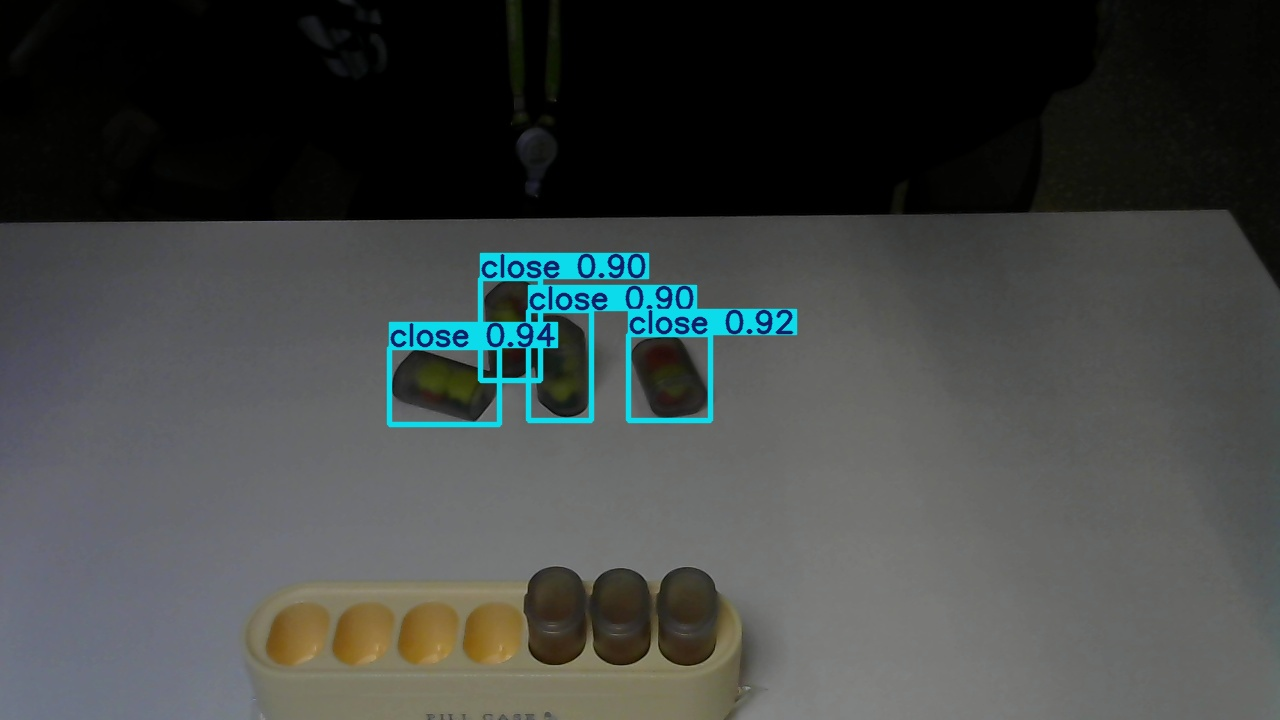

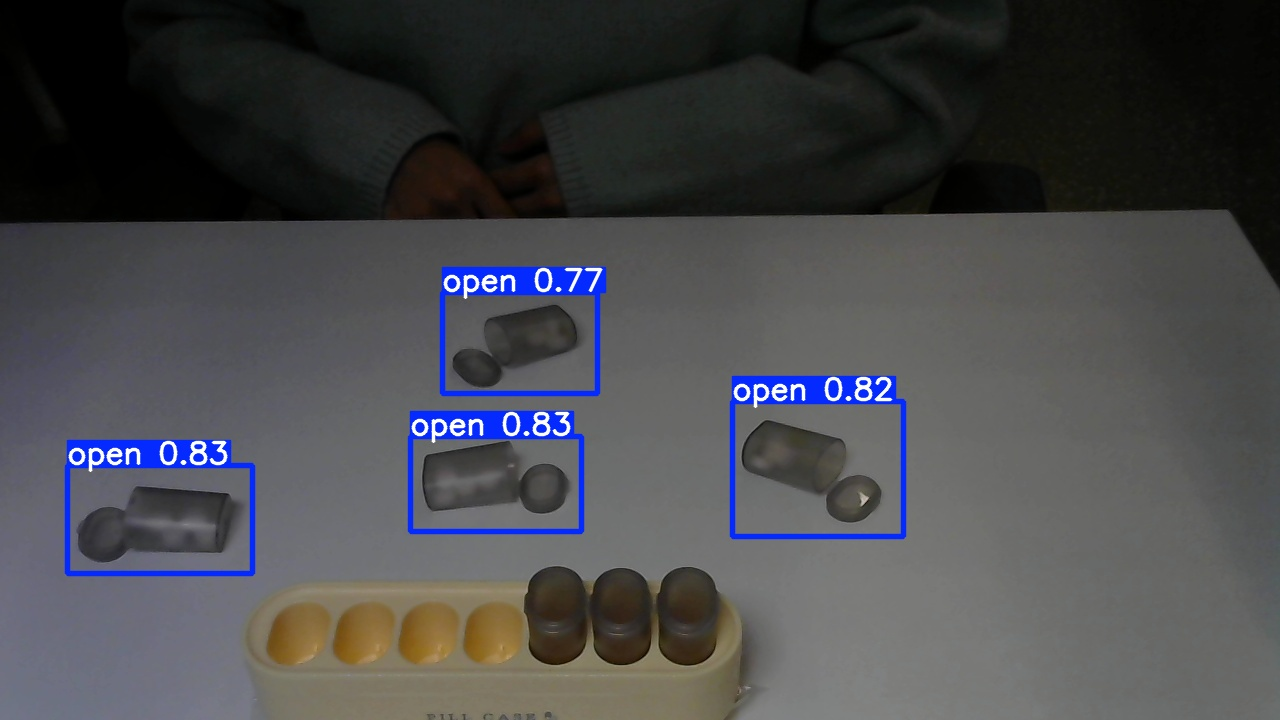

In [14]:
import glob
import os
import random
from IPython.display import Image, display

# ----- 1) val 이미지 3개 뽑기 -----
oc_val_images = glob.glob(os.path.join(OC_VAL_IMG_DIR, "*.*"))
oc_val_images = [p for p in oc_val_images if p.lower().endswith((".jpg", ".jpeg", ".png"))]

print(f"[Open/Close] val images: {len(oc_val_images)}장")

sample_oc_imgs = random.sample(oc_val_images, k=min(3, len(oc_val_images)))
print("샘플 이미지 (open/close):")
for p in sample_oc_imgs:
    print("  ", p)

# ----- 2) 추론 + 시각화 -----
results_oc = model_oc.predict(
    source=sample_oc_imgs,
    imgsz=640,
    conf=0.25,
    save=True,                      # bbox 그려진 이미지를 파일로 저장
    project="runs_vis_oc",          # 결과 저장 상위 폴더
    name="openclose_samples",       # 하위 폴더 이름
    exist_ok=True
)

# ----- 3) 저장된 결과 이미지 표시 -----
print("\n[Open/Close] 탐지 결과 시각화:")

# predict에서 save=True이면, 결과 이미지는
# results_oc[0].save_dir 아래에 원본 파일명으로 저장됨
save_dir_oc = results_oc[0].save_dir

for img_path in sample_oc_imgs:
    fname = os.path.basename(img_path)
    out_path = os.path.join(save_dir_oc, fname)
    if os.path.exists(out_path):
        display(Image(out_path))
    else:
        print("[WARN] not found:", out_path)


[Full/Empty] val images: 102장
샘플 이미지 (full/empty):
   /content/dataset_fullempty/images/val/photo_normal_204.jpg
   /content/dataset_fullempty/images/val/photo_normal_274.jpg
   /content/dataset_fullempty/images/val/photo_normal_399.jpg

0: 384x640 4 emptys, 4.2ms
1: 384x640 4 fulls, 4.2ms
2: 384x640 4 fulls, 4.2ms
Speed: 1.6ms preprocess, 4.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs_vis_fe/fullempty_samples

[Full/Empty] 탐지 결과 시각화:


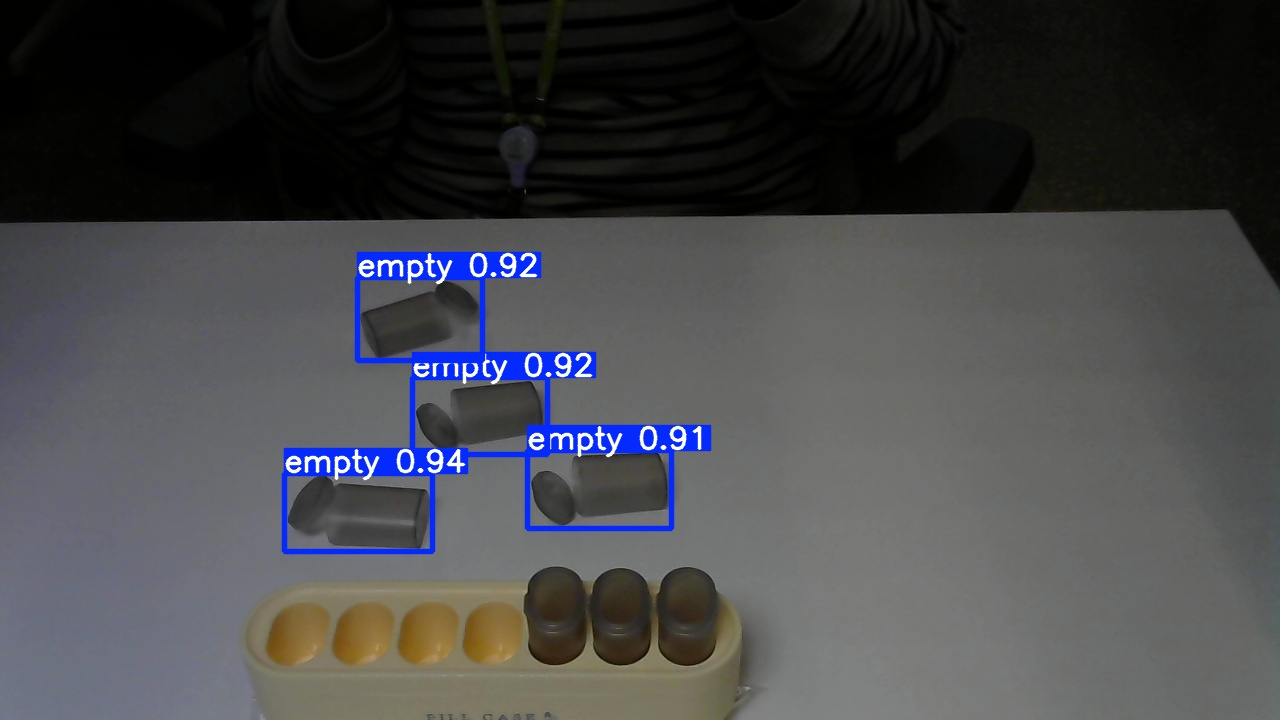

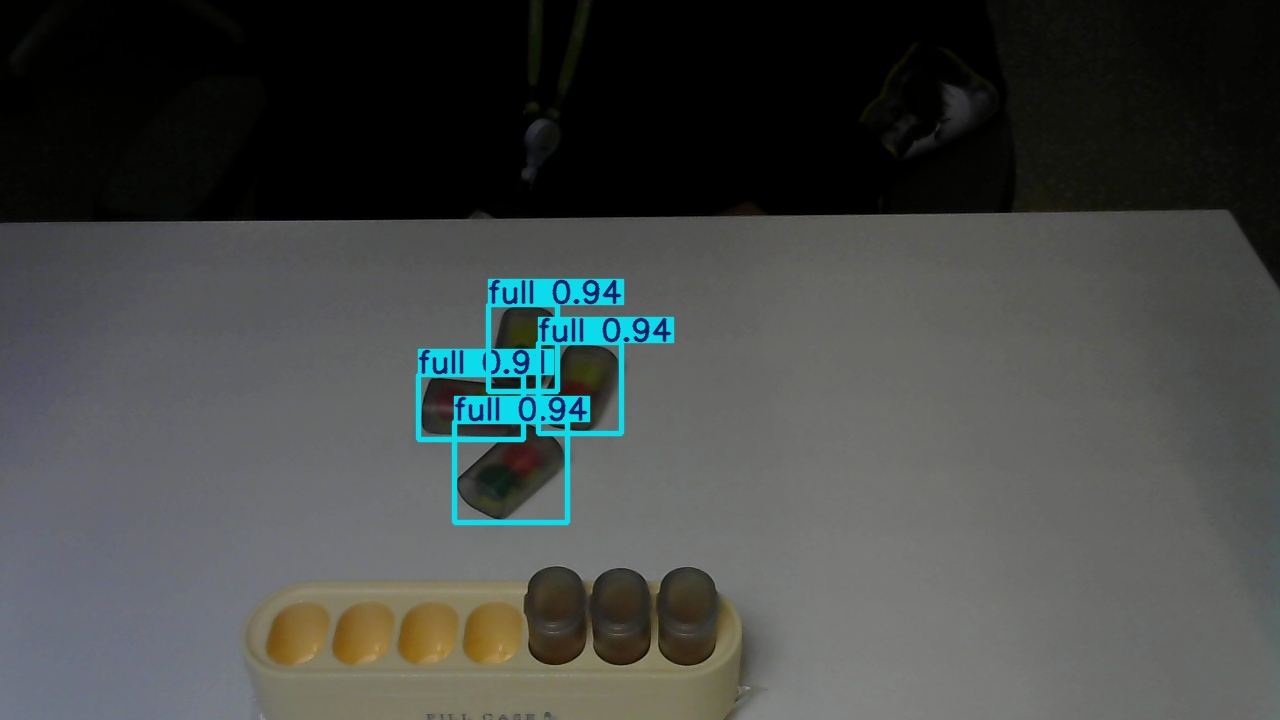

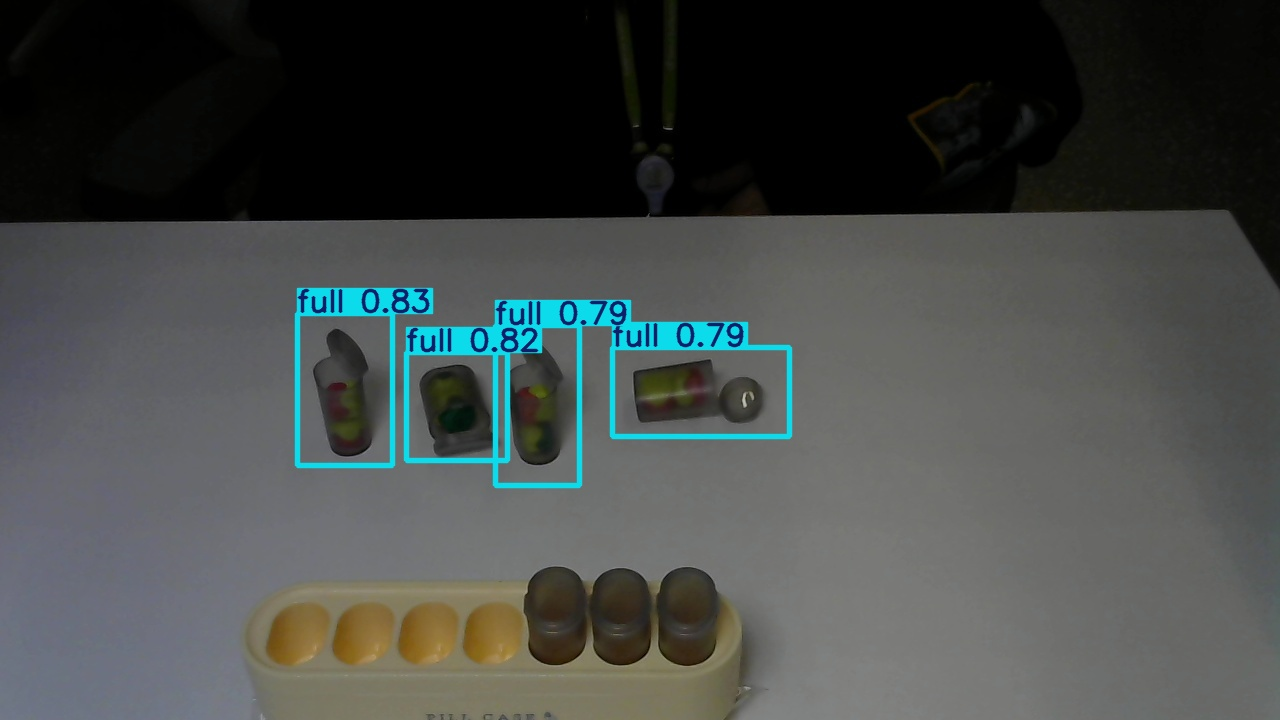

In [15]:
# ----- 1) val 이미지 3개 뽑기 -----
fe_val_images = glob.glob(os.path.join(FE_VAL_IMG_DIR, "*.*"))
fe_val_images = [p for p in fe_val_images if p.lower().endswith((".jpg", ".jpeg", ".png"))]

print(f"[Full/Empty] val images: {len(fe_val_images)}장")

sample_fe_imgs = random.sample(fe_val_images, k=min(3, len(fe_val_images)))
print("샘플 이미지 (full/empty):")
for p in sample_fe_imgs:
    print("  ", p)

# ----- 2) 추론 + 시각화 -----
results_fe = model_fe.predict(
    source=sample_fe_imgs,
    imgsz=640,
    conf=0.25,
    save=True,
    project="runs_vis_fe",
    name="fullempty_samples",
    exist_ok=True
)

# ----- 3) 저장된 결과 이미지 표시 -----
print("\n[Full/Empty] 탐지 결과 시각화:")

save_dir_fe = results_fe[0].save_dir

for img_path in sample_fe_imgs:
    fname = os.path.basename(img_path)
    out_path = os.path.join(save_dir_fe, fname)
    if os.path.exists(out_path):
        display(Image(out_path))
    else:
        print("[WARN] not found:", out_path)


In [16]:
import glob
import os
import random

# val 이미지 목록
oc_val_images = glob.glob(os.path.join(OC_VAL_IMG_DIR, "*.*"))
oc_val_images = [p for p in oc_val_images if p.lower().endswith((".jpg", ".jpeg", ".png"))]

print(f"[INFO] val 이미지 수: {len(oc_val_images)}")

# 최소 3장 이하라면 있는 만큼만 사용
N_SAMPLES = min(3, len(oc_val_images))
sample_imgs = random.sample(oc_val_images, k=N_SAMPLES)

print("\n[샘플로 사용할 이미지들]")
for p in sample_imgs:
    print("  ", p)


[INFO] val 이미지 수: 102

[샘플로 사용할 이미지들]
   /content/dataset_openclose/images/val/photo_normal_374.jpg
   /content/dataset_openclose/images/val/photo_normal_098.jpg
   /content/dataset_openclose/images/val/photo_normal_187.jpg



image 1/1 /content/dataset_openclose/images/val/photo_normal_374.jpg: 384x640 4 opens, 15.0ms
Speed: 4.4ms preprocess, 15.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/dataset_openclose/images/val/photo_normal_374.jpg: 384x640 4 fulls, 10.0ms
Speed: 1.8ms preprocess, 10.0ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)


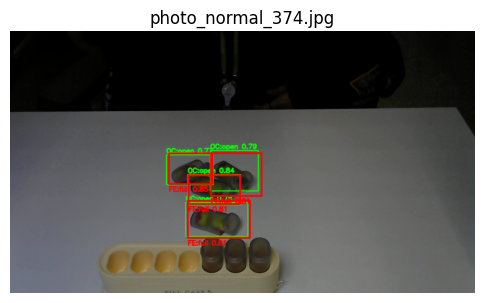


image 1/1 /content/dataset_openclose/images/val/photo_normal_098.jpg: 384x640 4 closes, 21.3ms
Speed: 5.1ms preprocess, 21.3ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/dataset_openclose/images/val/photo_normal_098.jpg: 384x640 4 emptys, 20.3ms
Speed: 2.0ms preprocess, 20.3ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


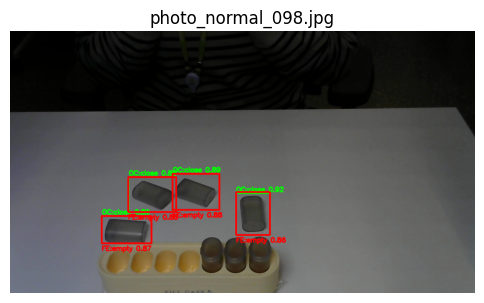


image 1/1 /content/dataset_openclose/images/val/photo_normal_187.jpg: 384x640 4 opens, 13.5ms
Speed: 2.1ms preprocess, 13.5ms inference, 4.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/dataset_openclose/images/val/photo_normal_187.jpg: 384x640 4 emptys, 11.0ms
Speed: 2.0ms preprocess, 11.0ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


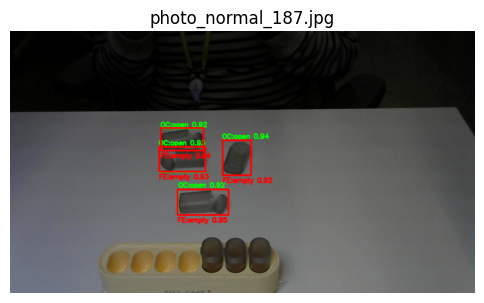

In [18]:
import cv2
import matplotlib.pyplot as plt
import os

# 클래스 이름 (학습할 때 쓴 순서와 맞춰야 함)
OC_NAMES = ["open", "close"]   # open/close 모델
FE_NAMES = ["empty", "full"]   # full/empty 모델

for img_path in sample_imgs:
    # 이미지 로드 (BGR -> RGB)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"[WARN] 이미지 로드 실패: {img_path}")
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # -------- 1) 두 모델로 각각 추론 --------
    res_oc = model_oc(img_path, imgsz=640, conf=0.25)[0]
    res_fe = model_fe(img_path, imgsz=640, conf=0.25)[0]

    # 시각화용 복사본
    vis = img_rgb.copy()

    # -------- 2) open/close 박스 (얇은 초록색) --------
    if res_oc.boxes is not None and len(res_oc.boxes) > 0:
        for box, cls, conf in zip(res_oc.boxes.xyxy, res_oc.boxes.cls, res_oc.boxes.conf):
            x1, y1, x2, y2 = box.tolist()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            cls = int(cls.item())
            label = f"OC:{OC_NAMES[cls]} {conf.item():.2f}"

            # 얇은 초록색 박스
            cv2.rectangle(
                vis,
                (x1, y1),
                (x2, y2),
                color=(0, 255, 0),   # BGR
                thickness=2
            )
            # 라벨 텍스트 (박스 위에)
            cv2.putText(
                vis,
                label,
                (x1, max(y1 - 5, 0)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2,
                cv2.LINE_AA
            )

    # -------- 3) full/empty 박스 (두꺼운 빨간색) --------
    if res_fe.boxes is not None and len(res_fe.boxes) > 0:
        for box, cls, conf in zip(res_fe.boxes.xyxy, res_fe.boxes.cls, res_fe.boxes.conf):
            x1, y1, x2, y2 = box.tolist()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            cls = int(cls.item())
            label = f"FE:{FE_NAMES[cls]} {conf.item():.2f}"

            # 더 두꺼운 빨간색 박스
            cv2.rectangle(
                vis,
                (x1, y1),
                (x2, y2),
                color=(255, 0, 0),   # BGR
                thickness=4
            )
            # 라벨 텍스트 (박스 아래쪽에)
            cv2.putText(
                vis,
                label,
                (x1, min(y2 + 20, vis.shape[0] - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2,
                cv2.LINE_AA
            )

    # -------- 4) 시각화 --------
    plt.figure(figsize=(6, 6))
    plt.title(os.path.basename(img_path))
    plt.imshow(vis)
    plt.axis('off')
    plt.show()
